In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from tensorflow.keras import utils
import keras_tuner as kt
import matplotlib.pyplot as plt

# Preprocessing cifar10 data

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

In [4]:
data = np.concatenate((X_train, X_test))
target = np.concatenate((y_train, y_test))

X, X_test, y, y_test = train_test_split(data, target, test_size=0.15)
X_train, X_val, y_train, y_val = train_test_split(X, y)

X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

y_train = utils.to_categorical(y_train, num_classes=10)
y_test = utils.to_categorical(y_test, num_classes=10)
y_val = utils.to_categorical(y_val, num_classes=10)

(10,)

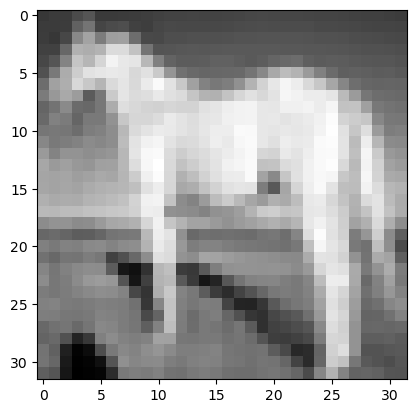

In [5]:
plt.imshow(X_train[10, :, :, 0], cmap="gray")
y_train[0].shape

# Creating the CNN model (RMSprop optimizer)

In [59]:
model = tf.keras.Sequential([
    keras.layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Dropout(0.2),
    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Dropout(0.2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='elu',
                       kernel_initializer="he_normal",
                       kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='elu',
                       kernel_initializer="he_normal",
                       kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='elu',
                       kernel_initializer="he_normal",
                       kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation='softmax')
])

In [60]:
model.compile(loss='crossentropy',
                         optimizer=keras.optimizers.RMSprop(),
                         metrics=["accuracy"])

In [61]:
model.fit(X_train, y_train,
             validation_data=(X_val, y_val),
             epochs=100,
             batch_size=128,
             callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)])

299/299 ━━━━━━━━━━━━━━━━━━━━ 113s 301ms/step - accuracy: 0.8454 - loss: 0.5395 - val_accuracy: 0.7666 - val_loss: 0.8238
Epoch 48/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 135s 451ms/step - accuracy: 0.8391 - loss: 0.5496 - val_accuracy: 0.7733 - val_loss: 0.7868


In [62]:
model.evaluate(X_test, y_test)

282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7703 - loss: 0.7979


[0.8114649653434753, 0.7645555734634399]

# Wide and deep model

In [6]:
input_ = keras.Input(shape=(32, 32, 3))
lyr1 = keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(input_)
lyr2 = keras.layers.Conv2D(64, (3, 3), activation='relu')(lyr1)
lyr3 = keras.layers.Conv2D(32, (3, 3), activation='relu')(lyr2)
lyr4 = keras.layers.Flatten()(lyr3)
lyr5 = keras.layers.MaxPooling2D((2, 2))(input_)
dropout_lyr1 = keras.layers.Dropout(0.2)(lyr5)
lyr6 = keras.layers.Flatten()(dropout_lyr1)

concatenate_lyr1 = keras.layers.Concatenate()([lyr4, lyr6])
output = keras.layers.Dense(10, activation='softmax')(concatenate_lyr1)

wan_model = keras.Model(inputs=input_, outputs=output)

In [7]:
wan_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 30, 30,    │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16, 3) │          0 │ input_layer[0][0] │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     18,464 │ conv2d_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 16, 3) │          0 │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 25088)     │          0 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 768)       │          0 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 25856)     │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │    258,570 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 315,754 (1.20 MB)

 Trainable params: 315,754 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
wan_model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [9]:
wan_model.fit(X_train, y_train,
              validation_data=(X_val, y_val),
              batch_size=128, epochs=100,
              callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)])

Epoch 1/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 67s 222ms/step - accuracy: 0.3525 - loss: 1.7891 - val_accuracy: 0.5270 - val_loss: 1.3259
Epoch 2/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 88s 293ms/step - accuracy: 0.5552 - loss: 1.2576 - val_accuracy: 0.5803 - val_loss: 1.1891
Epoch 3/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 91s 305ms/step - accuracy: 0.6321 - loss: 1.0550 - val_accuracy: 0.6386 - val_loss: 1.0472
Epoch 4/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 65s 217ms/step - accuracy: 0.6823 - loss: 0.9072 - val_accuracy: 0.6547 - val_loss: 1.0053
Epoch 5/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 27s 92ms/step - accuracy: 0.7189 - loss: 0.8066 - val_accuracy: 0.6444 - val_loss: 1.0243
Epoch 6/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 55s 183ms/step - accuracy: 0.7536 - loss: 0.7054 - val_accuracy: 0.6503 - val_loss: 1.0454
Epoch 7/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 115s 292ms/step - accuracy: 0.7903 - loss: 0.6064 - val_accuracy: 0.6565 - val_loss: 1.0513
Epoch 8/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 123s 228ms/step - accuracy: 0.8259 

In [10]:
wan_model.evaluate(X_test, y_test)

282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6010 - loss: 2.4717


[2.4554812908172607, 0.6001111268997192]

# Tuning the hyperparameters

In [ ]:
tuner = kt.tuners.RandomSearch(
  kt.applications.HyperResNet(input_shape=(32, 32, 3), classes=10),
  objective='val_accuracy',
  max_trials=30)

In [ ]:
# Run the search
tuner.search(X_train, y_train,
             validation_data= (X_train, y_test),
             epochs=30,
             callbacks=[tf.keras.callbacks.EarlyStopping(patience=2)])